In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.callbacks import EarlyStopping

import os


In [2]:
(x_train, _), (x_test, _) = cifar10.load_data()
# Normalize the data from 0-255 to 0-1 and link is to the original data website
# https://www.cs.toronto.edu/~kriz/cifar.html
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
print('Train:', x_train.shape, 'Test:', x_test.shape)

Train: (50000, 32, 32, 3) Test: (10000, 32, 32, 3)


In [3]:
input_img = Input(shape=(32, 32, 3))
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(8, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same', name='latent_space')(x)

x = Conv2D(8, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 8)        │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (MaxPooling2D)     │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 16)       │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,939 (54.45 KB)

 Trainable params: 13,939 (54.45 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
import os
import json
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Paths
model_dir = "models"
auto_path = os.path.join(model_dir, "autoencoder.weights.h5")
history_path = os.path.join(model_dir, "autoencoder_history.json")

# Create directory if not exist
os.makedirs(model_dir, exist_ok=True)

# --- TRAIN if weights not found ---
if not os.path.exists(auto_path):
    checkpoint = ModelCheckpoint(auto_path, monitor='val_loss', save_best_only=True, save_weights_only=True)
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = autoencoder.fit(
        x_train, x_train,
        epochs=40,
        batch_size=128,
        shuffle=True,
        validation_data=(x_test, x_test),
        callbacks=[checkpoint, early_stop]
    )

    # Save history
    with open(history_path, "w") as f:
        json.dump(history.history, f)

else:
    print(f"Loaded weights from {auto_path}")
    autoencoder.load_weights(auto_path)


Loaded weights from models\autoencoder.weights.h5


d:\Project_Ai\Deep-Learning-Projects-main\Deep-Learning-Projects-main\Autoencoder - Deep CNN - Copy (2)\my_ml_env\lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


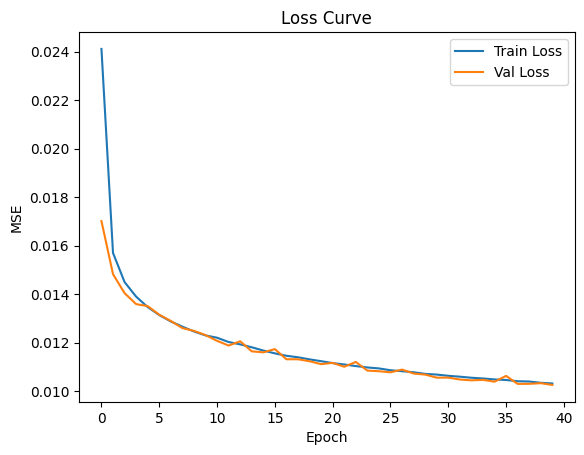

In [5]:
import json

# Load training history
with open("models/autoencoder_history.json", "r") as f:
    history = json.load(f)

# Plot Loss
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 612ms/step


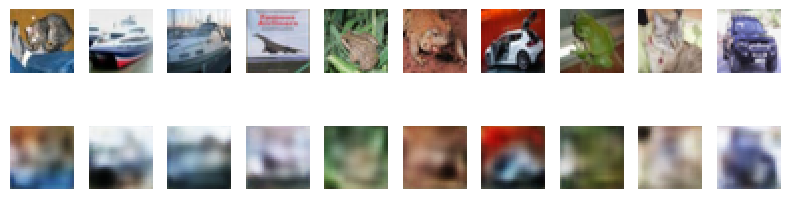

In [6]:
import matplotlib.pyplot as plt

decoded_imgs = autoencoder.predict(x_test[:10])

plt.figure(figsize=(8, 3))  # Width=20, Height=4 (you can adjust these values)

for i in range(10):
    # Original images
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i])
    plt.axis('off')

    # Reconstructed images
    ax = plt.subplot(2, 10, i + 11)
    plt.imshow(decoded_imgs[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


In [7]:

from tensorflow.keras import backend as K

# Create a function that returns the output of the latent space
from tensorflow.keras.models import Model

# Get the layer and build a model up to it
latent_model = Model(inputs=autoencoder.input, outputs=autoencoder.get_layer('latent_space').output)

# Generate a sample output to infer shape
latent_output = latent_model.predict(x_test[:1])  # just 1 image
latent_shape = latent_output.shape[1:]  # drop batch size

compressed = np.prod(latent_shape)
original = 32 * 32 * 3

print(f'Original size: {original} byte')
print(f'Compressed size: {compressed} byte')
print(f'Compression ratio: {original/compressed:.2f}:1')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
Original size: 3072 byte
Compressed size: 128 byte
Compression ratio: 24.00:1


In [8]:
# Load and prepare image
from tensorflow.keras.preprocessing import image
img_path = r"C:\Users\mhmd2\Pictures\Camera Roll\ChatGPT Image Apr 2, 2025, 03_44_01 PM.png"  # Notice the r for raw string
img = image.load_img(img_path, target_size=(32, 32))  # Resize to 32x32 

In [9]:
# Load full-size original image for display
original_img = image.load_img(img_path)
original_array = image.img_to_array(original_img).astype('float32') / 255.


In [10]:

# Load a second copy, resized to 32x32 for the model
model_input_img = image.load_img(img_path, target_size=(32, 32))
img_array = image.img_to_array(model_input_img).astype('float32') / 255.
img_array = np.expand_dims(img_array, axis=0)

print("Input shape for model:", img_array.shape)

Input shape for model: (1, 32, 32, 3)


In [11]:

# Run through autoencoder
reconstructed_img = autoencoder.predict(img_array)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step


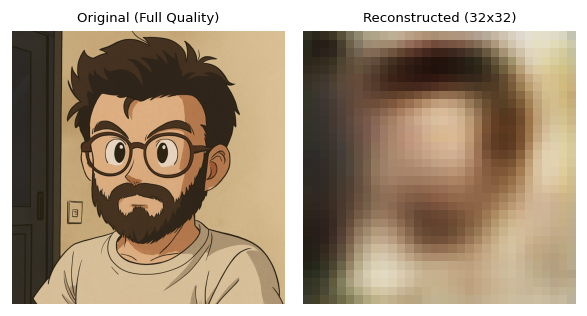

In [12]:
# Display: original (full quality) vs reconstructed (32x32)
plt.figure(figsize=(5, 3), dpi=120)

plt.subplot(1, 2, 1)
plt.imshow(original_array / np.max(original_array))
plt.title('Original (Full Quality)', fontsize=8)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_img[0], interpolation='nearest')
plt.title('Reconstructed (32x32)', fontsize=8)
plt.axis('off')

plt.tight_layout()
plt.show()